## Imports

In [2]:
from google.colab import drive
drive.mount('/content/drive')

#path = input("SIR_Model Folder Path: ")

Mounted at /content/drive


In [3]:
import os

os.chdir('/content/drive/My Drive/Colab Notebooks/Jax-Codes/SIR Model')
path = "/content/drive/My Drive/Colab Notebooks/Jax-Codes/SIR Model"

In [4]:
!pip install optuna
!pip install evojax
!pip install diffrax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 15.5 MB/s eta 0:00:00


In [5]:
import jax
import flax
import optax
from jax import lax, random, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from flax import linen as nn
from jax.scipy.linalg import solve
from functools import partial

import time
import numpy as np
import matplotlib.pyplot as plt

# choose GPU
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
jax.config.update("jax_enable_x64", True)

from evojax.util import get_params_format_fn
import optuna

from typing import Sequence, Callable

In [6]:
from diffrax import ODETerm, SaveAt, Tsit5, diffeqsolve, PIDController

config.update("jax_enable_x64", True)
config.update("jax_debug_nans", True)

## Generate Tasks

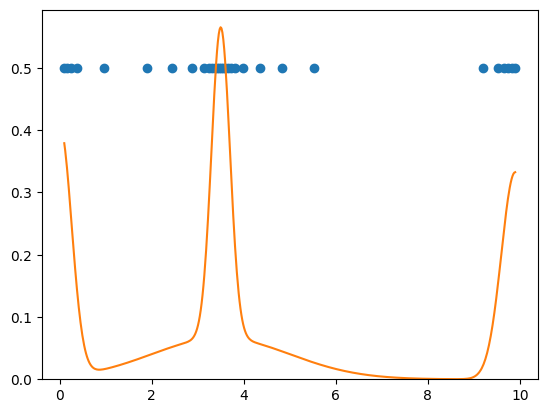

In [ ]:
# Source - https://stackoverflow.com/a/65424822
# Posted by JohanC
# Retrieved 2026-02-16, License - CC BY-SA 4.0

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

class sum_gaussians_gen(stats.rv_continuous):
    def _pdf(self, x):
        return (stats.norm.pdf(x, loc=3.5, scale=1.5) + stats.norm.pdf(x, loc=3.5, scale=0.2) + stats.norm.pdf(x, loc = 0.01, scale = 0.25) + stats.norm.pdf(x, loc = 9.9, scale = 0.3)) / 4

dist = sum_gaussians_gen()
bounds = dist.cdf([0.1, 9.9])
pp = np.linspace(*bounds, num=30)
vals = dist.ppf(pp)

plt.plot(vals, [0.5] * vals.size, 'o')
xs = np.linspace(0.1, 9.9, 500)
plt.plot(xs, dist.pdf(xs))
plt.ylim(ymin=0)
plt.show()

i_0 = jnp.asarray(vals) / 10

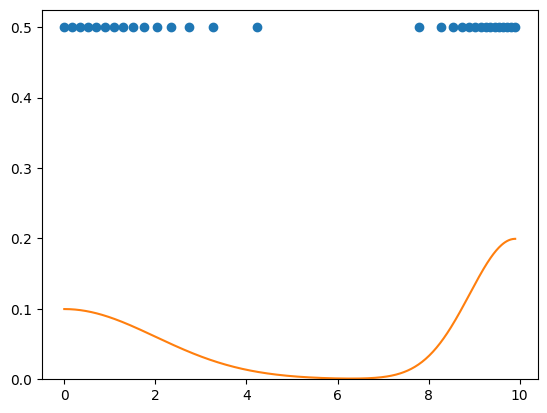

In [8]:
# Source - https://stackoverflow.com/a/65424822
# Posted by JohanC
# Retrieved 2026-02-16, License - CC BY-SA 4.0

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

class sum_gaussians_gen(stats.rv_continuous):
    def _pdf(self, x):
        return (stats.norm.pdf(x, loc=9.9, scale=1) + stats.norm.pdf(x, loc=0, scale=2)) / 2

dist = sum_gaussians_gen()
bounds = dist.cdf([0.0, 9.9])
pp = np.linspace(*bounds, num=30)
vals = dist.ppf(pp)

plt.plot(vals, [0.5] * vals.size, 'o')
xs = np.linspace(0.0, 9.9, 500)
plt.plot(xs, dist.pdf(xs))
plt.ylim(ymin=0)
plt.show()

r_0 = jnp.asarray(vals) / 10


In [ ]:
beta = jnp.array([0.5])
gamma = jnp.array([0.3])
control_unit = jnp.array([0])

B, G, U, I_0, R_0 = jnp.meshgrid(beta, gamma, control_unit, i_0, r_0, indexing='ij')

tasks = jnp.stack([B.flatten(), G.flatten(), U.flatten(), I_0.flatten(),R_0.flatten()], axis=-1)

indexes = []

for i in range(len(tasks)):
    if tasks[i,-1] + tasks[i,-2] <= 1:
        indexes.append(i)

tasks = tasks[jnp.asarray(indexes)]

print("Tasks shape:", tasks.shape)

Tasks shape: (435, 5)


## Standardised Constants

In [ ]:
t_vals = jnp.linspace(0, 1, 100)
shaped_tvals = t_vals.reshape(-1,1)
t_vals_solver = jnp.linspace(0, 1, 100)
seed = 100

inner_loop_iters = 3
scaling_factor = 1e3
baseline = 1e-7

## Solver Solutions

In [11]:
def ODE(t, y, args):
    beta, gamma, control_unit = args
    S, I, R = y
    dSdt = -beta * I * S
    dIdt = beta * I * S - (gamma + control_unit) * I
    dRdt = (gamma + control_unit) * I
    return jnp.stack([dSdt, dIdt, dRdt])

In [12]:
def ODE_sol(args):
    b, g, u, i, r = args


    term = ODETerm(ODE)
    solver = Tsit5()
    saveat = SaveAt(ts=t_vals_solver)
    t0 = t_vals_solver[0]
    t1 = t_vals_solver[-1]
    dt0 = float(t_vals_solver[1] - t_vals_solver[0])
    y_0 = jnp.array([(1.0 - i - r), i, r])  # Initial conditions: S0, I0, R0

    sol = diffeqsolve(
        term,
        solver,
        t0=t0,
        t1=t1,
        y0=y_0,
        dt0=dt0,
        args = [b, g, u],
        saveat= saveat,
    )

    return sol.ys

def batch_ODE_sol(tasks):
    batched_ode_sol = vmap(ODE_sol, in_axes=(0,))
    ode_sol = batched_ode_sol(tasks)

    return ode_sol

In [13]:
ode_sols = batch_ODE_sol(tasks)
print("ODE solutions shape:", ode_sols.shape)

ODE solutions shape: (435, 100, 3)


## Plot Solutions

## Split Training Data

In [14]:
key, rng = random.split(random.PRNGKey(seed), 2)

ran_index = jax.random.permutation(rng, tasks.shape[0])
train_index = ran_index[:int(0.8 * tasks.shape[0])]
test_index = ran_index[int(0.8 * tasks.shape[0]):]


train_data = (tasks[train_index], ode_sols[train_index])
test_data = (tasks[test_index], ode_sols[test_index])
print("Train data shape:", train_data[0].shape, train_data[1].shape)
print("Test data shape:", test_data[0].shape, test_data[1].shape)

Train data shape: (348, 5) (348, 100, 3)
Test data shape: (87, 5) (87, 100, 3)


## Loss Function

In [15]:
def regularization_factor(params):
  reg = 10**(nn.tanh(params)* 3 - 2)

  return reg

## Initialise PINN

In [16]:
act_fn_by_name = {
    "sigmoid": nn.sigmoid,
    "tanh": nn.tanh,
    "relu": nn.relu,
    "elu": nn.elu,
    "celu": nn.celu,
    "swish": nn.swish
}

In [17]:
act_fn_names = ["sigmoid", "tanh", "relu", "elu", "celu", "swish"]

In [18]:
# PINC
# TRY to split into 2 fs also

class PINC(nn.Module):
    """PINNs"""
    layer_sizes: Sequence[int]
    act_funcs: Sequence[str]


    @nn.compact
    def __call__(self, t_vals):
        # split the two variables, probably just by slicing
        # t = inputs
        t = t_vals

        act_fn_by_name = {
            "sigmoid": nn.sigmoid,
            "tanh": nn.tanh,
            "relu": nn.relu,
            "elu": nn.elu,
            "celu": nn.celu,
            "swish": nn.swish
        }

        def get_u(t):
            # f = t / 10 - 0.4
            f = t # TRY THIS
            fs = []
            for i, (size, str) in enumerate(zip(self.layer_sizes, self.act_funcs)):
                f = nn.Dense(size, kernel_init=jax.nn.initializers.he_uniform(), use_bias=True)(f)

                if i == 0:
                    pre_act = f

                funcs = act_fn_by_name[str]

                f = funcs(f)
                fs.append(f)

            fs = jnp.hstack(fs)
            return f, pre_act, fs

        f, pre_act, fs = get_u(t)

        # obtain f_t
        def get_f_dir(get_u, t):
            # f_t = jacfwd(get_u)(t)  # much faster (10x) than u_xx, f_xx = hessian(get_u)(x, y)
            f_t = jacfwd(lambda t: get_u(t)[0])(t)  # much faster (10x) than u_xx, f_xx = hessian(get_u)(x, y)

            f_t = jnp.squeeze(f_t, axis= -1)
            return f_t

        f_dir_vmap = vmap(get_f_dir, in_axes=(None, 0))
        f_t = f_dir_vmap(get_u, t)


        outputs = jnp.hstack([f, f_t])

        return outputs, pre_act

## Training

In [ ]:
def objective(trial):

    seed = 0
    key, rng = random.split(random.PRNGKey(seed), 2)

    n_layers = trial.suggest_int("n_layers", 1, 5)
    layer_size = trial.suggest_int("layer_size", 10, 500)
    sr_ratio = trial.suggest_float("sr_ratio", 0.1, 0.4)

    sr_nodes = int(layer_size * sr_ratio)

    if sr_nodes < 1:
      raise optuna.TrialPruned()

    i_nodes = layer_size - sr_nodes


    layer_sizes = []
    act_funcs = []

    for i in range(n_layers):
        layer_sizes.append(layer_size)

        act_name = trial.suggest_categorical(f"layer{i}_activation", act_fn_names)
        act_funcs.append(act_name)

    layer_sizes = tuple(layer_sizes)
    act_funcs = tuple(act_funcs)


    model = PINC(layer_sizes=layer_sizes, act_funcs=act_funcs)
    a = random.normal(key, [1,1])
    params = model.init(key, a)
    num_params, format_params_fn = get_params_format_fn(params)

    # flatten initial params
    params = jax.flatten_util.ravel_pytree(params)[0]

    # for inverst problem - append params to include 2 more parameters
    key, rng = random.split(rng) # update random generator
    ini_a = random.normal(key, [1, 1]) #one lambda
    params = jnp.append(params, ini_a)

    max_iters = trial.suggest_int("max_iters", 1, 2000)
    max_lr = trial.suggest_float("max_lr", 1e-5, 9e-1, log=True)
    min_lr = trial.suggest_float("min_lr", 1e-9, 1e-3, log=True)
    lr_exp = trial.suggest_float("lr_exp", 0.1, 3)
    batch_size = trial.suggest_int("batch_size", 1, 300)

    lr_scheduler = optax.warmup_cosine_decay_schedule(init_value=max_lr, peak_value=max_lr, warmup_steps=0,
                                                  decay_steps= (max_iters), end_value=min_lr, exponent= lr_exp)

    optimizer = optax.adam(learning_rate=lr_scheduler)
    opt_state = optimizer.init(params)

    def eval_loss(params, args, sol):

        # Apply Model
        pred, pre_act = model.apply(format_params_fn(params[:-1]), shaped_tvals)
        f, f_t = jnp.split(pred, 2, axis=1)
        fS, fI, fR = jnp.split(f, [sr_nodes, i_nodes], axis=1)
        f_tS, f_tI, f_tR = jnp.split(f_t, [sr_nodes, i_nodes], axis=1)


        # Unpack task
        beta, gamma, control_unit, i_initial, r_initial = args[0],  args[1], args[2], args[3], args[4]

        # Unpack solution
        y1_sol = sol[:,0]
        y2_sol = sol[:,1]
        y3_sol = sol[:,2]

        # Unpack regularization param
        reg = regularization_factor(params[-1])

        s_0 = 1.0 - i_initial - r_initial
        i_0 = i_initial
        r_0 = r_initial

        def pseudo_(y_vals, _):

            # Unpack y_vals
            y1 = y_vals[0]
            y2 = y_vals[1]
            y3 = y_vals[2]

            # First ODE
            s_coefficient = beta * y2
            A1 = jnp.concatenate([f_tS + s_coefficient * fS, jnp.zeros_like(fI), jnp.zeros_like(fR)], axis=1)
            A1_bc = jnp.concatenate([fS[0], jnp.zeros_like(fI[0]), jnp.zeros_like(fR[0])])
            A1 = A1.at[0].set(A1_bc)
            b1 = jnp.zeros_like(shaped_tvals) + 1e-12
            b1 = b1.at[0].set(s_0 * scaling_factor)

            # Second ODE
            i_coefficient = - beta * y1 + (gamma + control_unit)
            A2 = jnp.concatenate([jnp.zeros_like(fS), f_tI + i_coefficient * fI, jnp.zeros_like(fR)], axis=1)
            A2_bc = jnp.concatenate([jnp.zeros_like(fS[0]), fI[0], jnp.zeros_like(fR[0])])
            A2 = A2.at[0].set(A2_bc)
            b2 = jnp.zeros_like(shaped_tvals) + 1e-12
            b2 = b2.at[0].set(i_0 * scaling_factor)

            # Third ODE
            A3 = jnp.concatenate([jnp.zeros_like(fS), -(gamma + control_unit) * fI, f_tR], axis=1)
            A3_bc = jnp.concatenate([jnp.zeros_like(fS[0]), jnp.zeros_like(fI[0]), fR[0]])
            A3 = A3.at[0].set(A3_bc)
            b3 = jnp.zeros_like(shaped_tvals) + 1e-12
            b3 = b3.at[0].set(r_0 * scaling_factor)



            # Combine both ODEs
            A = jnp.concatenate([A1, A2, A3], axis=0)
            b_vec = jnp.concatenate([b1, b2, b3], axis=0)

            # Pseudoinverse solution with regularization
            As, bs = (A.T@A) + reg * jnp.eye(A.shape[1]), A.T@b_vec  #this is least squares  (A.T@A)
            w_PI = solve(As, bs)

            y1 = fS @ w_PI[:sr_nodes]
            y2 = fI @ w_PI[sr_nodes:-sr_nodes]
            y3 = fR @ w_PI[-sr_nodes:]



            y1 = y1 / scaling_factor
            y2 = y2 / scaling_factor
            y3 = y3 / scaling_factor

            y_vals = jnp.stack([y1, y2, y3])

            return y_vals, w_PI

        y_init = jnp.stack([jnp.ones_like(shaped_tvals) * s_0, jnp.ones_like(shaped_tvals) * i_0, jnp.ones_like(shaped_tvals) * r_0])
        y_vals, w_PIs = lax.scan(pseudo_, y_init, None, length=inner_loop_iters)
        y1 = y_vals[0]
        y2 = y_vals[1]
        y3 = y_vals[2]
        w_PI = w_PIs[-1]

        #jax.debug.print("S_0 BC: {x}, s_0 given BC: {s_0}", x = y1[0], s_0 = s_0)


        rl2_y1 = jnp.linalg.norm(y1_sol.reshape(-1, 1) - y1) / (jnp.linalg.norm(y1_sol.reshape(-1, 1) + 1e-3))
        rl2_y2 = jnp.linalg.norm(y2_sol.reshape(-1, 1) - y2) / (jnp.linalg.norm(y2_sol.reshape(-1, 1) + 1e-3))
        rl2_y3 = jnp.linalg.norm(y3_sol.reshape(-1, 1) - y3) / (jnp.linalg.norm(y3_sol.reshape(-1, 1) + 1e-3))


        data_loss = rl2_y1 / 2.5 + rl2_y2 + rl2_y3 / 100

        #jax.debug.print("y1: {x}, y2: {y}, y3 {z}", x=rl2_y1, y = rl2_y2, z = rl2_y3)

        u_reshaped = jnp.reshape(control_unit, (-1, 1))

        PDE_loss_1 = jnp.mean(jnp.square((f_tS @ w_PI[:sr_nodes])/scaling_factor + beta * y2 * y1))
        PDE_loss_2 = jnp.mean(jnp.square((f_tI @ w_PI[sr_nodes:-sr_nodes])/scaling_factor + (-beta * y1 + (gamma + control_unit)) * y2))
        PDE_loss_3 = jnp.mean(jnp.square((f_tR @ w_PI[-sr_nodes:])/scaling_factor - (gamma + control_unit) * y2))

        PDE_loss = PDE_loss_1 / 2.5 + PDE_loss_2 + PDE_loss_3 / 100
        PDE_loss = PDE_loss

        sum_loss = jnp.mean(jnp.abs(y1 + y2 + y3 - 1)) / 500

        loss =  data_loss + PDE_loss + sum_loss

        loss = jnp.squeeze(loss + 1e-6)
        PDE_loss = jnp.squeeze(PDE_loss + 1e-6)
        data_loss = jnp.squeeze(data_loss + 1e-6)
        sum_loss = jnp.squeeze(sum_loss + 1e-6)



        return loss, (PDE_loss, data_loss, sum_loss, reg)

    loss_grad = jit(jax.value_and_grad(eval_loss, has_aux=True))



    # weights update

    @jit
    def update(params, opt_state, tasks, sol):
        (loss, (PDE_loss, data_loss, sum_loss, reg)), grad0 = loss_grad(params, tasks, sol)
        return loss, PDE_loss, data_loss, sum_loss, reg, grad0


    batch_update = jit(vmap(update, in_axes=(None, None, 0, 0)))

    @jit
    def update1(params, opt_state, grads):
        updates, opt_state = optimizer.update(grads, opt_state)
        params = optax.apply_updates(params, updates)
        return params, opt_state

    def one_train_loop(state, _):
      params, opt_state, current_rng, iters, probs = state

      current_key, current_rng = random.split(current_rng) # update random generator
      task_list = jax.random.choice(current_key, train_data[0].shape[0], (batch_size,), replace=False, p = probs)
      #task_list = jnp.array([3, 3, 3])  # for debugging

      loss, PDE_loss, data_loss, sum_loss, reg, grad0 = batch_update(params, opt_state, train_data[0][task_list], train_data[1][task_list])

      probs = probs.at[task_list].set(loss + baseline)

      loss_weights = loss / jnp.sum(loss)
      scaled_grad0 = grad0 * loss_weights[:,jnp.newaxis]


      loss, PDE_loss, data_loss, sum_loss, reg, grad0 = jnp.sum(loss) / batch_size, jnp.sum(PDE_loss) / batch_size, jnp.sum(data_loss) / batch_size, jnp.sum(sum_loss) / batch_size, jnp.sum(reg) / batch_size, jnp.sum(scaled_grad0, axis=0) / batch_size

      params, opt_state = update1(params, opt_state, grad0)

      return (params, opt_state, current_rng, iters + 1, probs), jnp.array([iters, loss, PDE_loss, data_loss, reg, task_list[0], task_list[1], task_list[2]])

    probs = jnp.ones(train_data[0].shape[0]) * 100

    train_iters = 0
    state = (params, opt_state, rng, train_iters, probs)

    eval_interval = 100
    num_chunks = max_iters // eval_interval
    remainder = max_iters % eval_interval

    for chunk in range(num_chunks):
        state, store_array = lax.scan(one_train_loop, state, None, length=eval_interval)

        current_loss = store_array[:, 1][-1].item()
        current_step = (chunk + 1) * eval_interval

        #trial.report(current_loss, current_step)
        if trial.should_prune():
            raise optuna.TrialPruned()

        final_loss = current_loss

    if remainder > 0:
        state, store_array = lax.scan(one_train_loop, state, None, length=remainder)
        final_loss = store_array[:, 1][-1].item()

    return final_loss

In [23]:
study = optuna.create_study(study_name = "SIR_trial",direction="minimize")
study.optimize(objective, n_trials = 300)

pruned_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
trial = study.best_trial

with open("Study_Summary.txt", 'w') as f:

  f.write(f"""
        Study Statistics:

        Number of Finished Trials: {len(study.trials)}

        Number of Pruned Trials: {len(pruned_trials)}

        Number of Completed Trials: {len(completed_trials)}

        Best Trial: \n Value: {trial.value}

        Params:
        """)

  for key, value in trial.params.items():
    f.write(f"{key}: {value}\n")

[I 2026-04-23 00:44:07,898] A new study created in memory with name: SIR_trial
[I 2026-04-23 00:44:26,290] Trial 0 finished with value: 0.007289189772618646 and parameters: {'n_layers': 4, 'layer_size': 141, 'sr_ratio': 0.37041589129141583, 'layer0_activation': 'swish', 'layer1_activation': 'relu', 'layer2_activation': 'elu', 'layer3_activation': 'elu', 'max_iters': 279, 'max_lr': 0.23866970548308472, 'min_lr': 4.171814126524179e-06, 'lr_exp': 0.3569012389873283, 'batch_size': 140}. Best is trial 0 with value: 0.007289189772618646.
[I 2026-04-23 00:46:35,132] Trial 1 finished with value: 0.06961344422985624 and parameters: {'n_layers': 4, 'layer_size': 367, 'sr_ratio': 0.14505886106649551, 'layer0_activation': 'sigmoid', 'layer1_activation': 'sigmoid', 'layer2_activation': 'sigmoid', 'layer3_activation': 'sigmoid', 'max_iters': 1252, 'max_lr': 0.025869897282662906, 'min_lr': 5.3054276526225434e-08, 'lr_exp': 0.588528399219862, 'batch_size': 280}. Best is trial 0 with value: 0.007289189

## Visualisations

In [20]:
!pip install -U kaleido==0.2.1
from optuna.visualization import plot_contour, plot_param_importances


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 34.4 MB/s eta 0:00:00


In [24]:
fig1 = plot_contour(study)
fig1.write_image("contour_plot", format = 'png')

In [25]:
fig2 = plot_param_importances(study)
fig2.write_image("param_importances_plot", format = 'png')


In [26]:
fig3 = plot_param_importances(
    study, target=lambda t: t.duration.total_seconds(), target_name="duration"
)
fig3.write_image("param_time_importances_plot", format = 'png')

In [ ]:
# No need to copy once I change the directory for running
source_dir = "/content/"
dest_dir = f"{path}"

print(f"Source directory: {source_dir}")
print(f"Destination directory: {dest_dir}")


items = ["Study_Summary.txt", "contour_plot", "param_importances_plot", "param_time_importances_plot"]
for item in  items:
  dir = source_dir+item
  !cp -r "{dir}" "{dest_dir}"